In [ ]:
!pip install netCDF4
!pip install pysolar

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysolar.solar import *
import datetime

import operator

from itertools import combinations

# Proper verification
from sklearn.metrics import *

from google.colab import files

import tensorflow as tf
sess = tf.compat.v1.InteractiveSession()

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, Flatten, \
    LSTM, GRU, Concatenate, BatchNormalization, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.4.1


/usr/local/lib/python3.7/dist-packages/tensorflow/python/client/session.py:1761: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


In [ ]:
from datetime import datetime, timedelta
from netCDF4 import Dataset

from google.colab import drive, files
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Model Data
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_model.npy')

# Obs Data 
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_obs.npy') 

# Precomputed SZA
sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_sza.npy', allow_pickle=True)

cc_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_cc.npy')

sh_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_sh.npy')

In [ ]:
# Remove all the max visibility cases
max_vis = obs_data[:,0] != obs_data[:,0].max()
obs_data = obs_data[max_vis,]
model_data = model_data[max_vis,]
sza = sza[max_vis]
cc_data = cc_data[max_vis]
sh_data = sh_data[max_vis]

In [ ]:
obs_data_vis = obs_data[:,0]

obs_data_T = obs_data[:,2]
obs_data_Td = obs_data[:,3]
sza = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

model_data_T = model_data[:,:,1]
model_data_Td = model_data[:,:,2]

In [ ]:
# Bin the data
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

In [ ]:
  # Use the past_history nr of data to predict future_target nr of data
  past_history = 6
  future_target = 4

  
  # Split into training data
  TRAIN_SPLIT = np.int(0.8*len(obs_data_vis))
  print(TRAIN_SPLIT)

  STEP = 1

14343


In [ ]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [ ]:
def multi_layer_cross_entropy(y_true, y_pred):



  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:])

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    print("=================")
    a = y_true_step_i
    a = tf.Print(a, [a], message="This is a: ")
    a.eval()
    b = y_pred_step_i
    b = tf.Print(b, [b], message="This is a: ")
    b.eval()    
    print("=================")
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, 
                                                              y_pred_step_i)
  
  return loss

In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [ ]:
def categorical_skill_scores(y_true, y_pred, labels=[0,1,2,3,4,5,6,7]):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [ ]:
def automate_features(feat_list) :

  auxil_feat = len(feat_list)

  obs_data_list = []

  for i in range(auxil_feat) :

    temp_data = feat_list[i]

    obs_data_list.append(temp_data)


  # This is the visibility (target) dataset
  x_train_vis, y_train_vis = multivariate_data_obs(obs_data_vis, obs_data_vis, 0,
                                                  TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_vis, y_val_vis = multivariate_data_obs(obs_data_vis, obs_data_vis,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)


  x_train_T_obs, _ = multivariate_data_obs(obs_data_T, obs_data_T, 0,
                                                  TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_T_obs, _ = multivariate_data_obs(obs_data_T, obs_data_T,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)

  x_train_Td_obs, _ = multivariate_data_obs(obs_data_Td, obs_data_Td, 0,
                                                  TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_Td_obs, _ = multivariate_data_obs(obs_data_Td, obs_data_Td,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)
  
  x_train_T_model, _ = multivariate_data_model(model_data_T, model_data_T, 0,
                                                  TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_T_model, _ = multivariate_data_model(model_data_T, model_data_T,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)

  x_train_Td_model, _ = multivariate_data_model(model_data_Td, model_data_Td, 0,
                                                  TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_Td_model, _ = multivariate_data_model(model_data_Td, model_data_Td,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)

  x_train_sza, _ = multivariate_data_model(sza, sza, 0,
                                                 TRAIN_SPLIT, past_history,
                                                  future_target, STEP)
  x_val_sza, _ = multivariate_data_model(sza, sza,
                                              TRAIN_SPLIT, None, past_history,
                                              future_target, STEP)

  x_train_list = []

  x_val_list = []

  
  for i in range(auxil_feat) :

    x_train_temp_obs, _ = multivariate_data_obs(obs_data_list[i], obs_data_list[i], 0,
                                                    TRAIN_SPLIT, past_history,
                                                    future_target, STEP)
    

    x_val_temp_obs, _ = multivariate_data_obs(obs_data_list[i], obs_data_list[i],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)


    x_train_list.append(x_train_temp_obs)

    x_val_list.append(x_val_temp_obs)
  
  plt.hist(x_train_vis[:,0],bins=8)



  # Using T-Td as feature
  x_train_TTd_obs = x_train_T_obs-x_train_Td_obs
  x_val_TTd_obs = x_val_T_obs-x_val_Td_obs

  x_train_TTd_model = x_train_T_model-x_train_Td_model
  x_val_TTd_model = x_val_T_model-x_val_Td_model




  x_train_norm_list = []

  x_val_norm_list = []

  for i in range(auxil_feat) :

    temp_max = np.max(x_train_list[i]) 
    temp_min = np.min(x_train_list[i])

    temp_norm_train = (x_train_list[i] - temp_min)/(temp_max - temp_min)

    temp_norm_val = (x_val_list[i] - temp_min)/(temp_max - temp_min)

    x_train_norm_list.append(temp_norm_train)

    x_val_norm_list.append(temp_norm_val)


  # Concatenate the data

  x_train_model = np.concatenate((x_train_T_model, x_train_TTd_model, x_train_sza), axis=2)

  x_val_model = np.concatenate((x_val_T_model, x_val_TTd_model, x_val_sza), axis=2)


 
  x_train_obs = x_train_norm_list[0]

  x_val_obs = x_val_norm_list[0]

  for i in range(auxil_feat - 1) :

    x_train_obs = np.stack(tuple(x_train_norm_list), axis = 2)

    x_val_obs = np.stack(tuple(x_val_norm_list), axis = 2)


  print(x_train_model.shape)
  print(x_train_obs.shape)


  # Total number of model features
  nr_features_model = x_train_model.shape[2]
  nr_features_obs = x_train_obs.shape[2]


  # Data shape
  print ('Single window of past history : {}'.format(x_train_model[0].shape))
  print ('Target visibility to predict : {}'.format(y_train_vis[0].shape))

  input_shape_model = (past_history+future_target, nr_features_model,)
  input_shape_obs = (past_history, nr_features_obs,)

  # Obs branch
  in_obs = Input(shape=input_shape_obs)
  b_obs = LSTM(128, return_sequences=False, recurrent_dropout=0.0, 
                    dropout=0.)(in_obs)

  # Model branch
  in_model = Input(shape=input_shape_model)
  b_model = LSTM(128, return_sequences=False, recurrent_dropout=0.0, 
                    dropout=0.)(in_model)               

  # Now concatenate with all branches
  b = Concatenate()([b_obs, b_model])
  b = Dense(128*future_target, activation='selu')(b)
  b = Dropout(0.5)(b)
  b = Reshape((future_target, 128))(b)
  b = LSTM(128, return_sequences=True, recurrent_dropout=0.0)(b)
  out = TimeDistributed(Dense(8, activation='softmax'))(b)

  model = Model([in_obs, in_model], out)
  model.compile(optimizer='adam', loss=multi_layer_cross_entropy,
                metrics=['acc'])
  model.summary()


  multi_step_history = model.fit([x_train_obs, x_train_model], 
                               y_train_vis, batch_size=256,
                               validation_split=0.05, epochs=40,
                               callbacks=tf.keras.callbacks.EarlyStopping(patience=5))


  plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')


  # Plot some results
  ix = np.random.randint(0, len(x_val_vis))

  vis = np.expand_dims(x_val_vis[ix,], axis=0)
  true_vis = np.expand_dims(y_val_vis[ix,], axis=0)
  data_obs = np.expand_dims(x_val_obs[ix,], axis=0)
  data_model = np.expand_dims(x_val_model[ix,], axis=0)
  # sza = np.expand_dims(x_val_sza[ix,], axis=0)

  runs = 20
  vis_prob = np.stack([model([data_obs, data_model], training=True) \
                      for sample in range(runs)])
  vis_prob = np.argmax(vis_prob, axis=3)

  vis_mean = np.round(vis_prob.mean(axis=0))
  vis_std = vis_prob.std(axis=0)

  # This is the input observations
  plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

  # Persitence prediction
  plt.plot(np.arange(1, future_target+1), x_val_vis[ix, past_history-1]*np.ones(future_target),'g.')

  # ML prediction
  plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')
  plt.fill_between(np.arange(1, future_target+1), vis_mean[0,]-vis_std[0,], vis_mean[0,]+vis_std[0,])

  # True observed future
  plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

  plt.legend(['Observed past','Persistence','ML model','Observed']) 
  plt.grid()
  plt.xlabel('time')
  plt.ylabel('class')

  # for i in range(runs):
  #  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')


  res = model([data_obs, data_model], training=True)[0,].numpy()
  print(res.sum(axis=1))

  # Now verify the model
  n_val = len(x_val_vis)
  y_pers = np.zeros((n_val, future_target))
  y_ml = np.zeros((n_val, future_target))

  err_pers = np.zeros(n_val)
  err_ml = np.zeros(n_val)

  for i in range(n_val):

    # 1) Persistence error
    y_pers[i,] = x_val_vis[i, past_history-1]*np.ones(future_target)
    err_pers[i] = np.mean(np.square(y_pers[i,] - y_val_vis[i,]))

    # 3) ML model error
    vis = np.expand_dims(x_val_vis[i,], axis=0)
    true_vis = np.expand_dims(y_val_vis[i,], axis=0)
    data_obs = np.expand_dims(x_val_obs[i,], axis=0)
    data_model = np.expand_dims(x_val_model[i,], axis=0)

    vis_ml = model([data_obs, data_model])
    vis_ml = np.argmax(vis_ml, axis=2)
    
    err_ml[i] = np.mean(np.square(vis_ml[0,] - y_val_vis[i,]))
    y_ml[i,:] = vis_ml[0,]

  print('Persistence error: {}'.format(np.sum(err_pers)))
  print('ML model error: {}'.format(np.sum(err_ml)))

  nr_classes = 8

  precision_pers = np.zeros((nr_classes,future_target))
  recall_pers = np.zeros((nr_classes,future_target))
  f1_pers = np.zeros((nr_classes,future_target))
  balanced_acc_pers = np.zeros(future_target)

  precision_ml = np.zeros((nr_classes,future_target))
  recall_ml = np.zeros((nr_classes,future_target))
  f1_ml = np.zeros((nr_classes,future_target))
  balanced_acc_ml = np.zeros(future_target)

  for i in range(future_target):
    precision_pers[:,i] = precision_score(y_val_vis[:,i], y_pers[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)
    precision_ml[:,i] = precision_score(y_val_vis[:,i], y_ml[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)

    recall_pers[:,i] = recall_score(y_val_vis[:,i], y_pers[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)
    recall_ml[:,i] = recall_score(y_val_vis[:,i], y_ml[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)

    f1_pers[:,i] = f1_score(y_val_vis[:,i], y_pers[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)
    f1_ml[:,i] = f1_score(y_val_vis[:,i], y_ml[:,i], 
                                          labels=[0,1,2,3,4,5,6,7], average=None)
    
    balanced_acc_pers[i] = balanced_accuracy_score(y_val_vis[:,i], y_pers[:,i])
    balanced_acc_ml[i] = balanced_accuracy_score(y_val_vis[:,i], y_ml[:,i])

  np.set_printoptions(precision=2)
  for i in range(future_target):
    HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_ml[:,i])
    print('Prediction step {}:'.format(i+1))
    print('F1-score ML: {}'.format(f1_ml[:,i]))
    print('F1-score PE: {}'.format(f1_pers[:,i]))
    print('Balanced accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
    print('Balanced accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
    print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
    HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_pers[:,i])
    print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

  for i in range(1):
    print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
    print(classification_report(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
    print('Confusion matrix:\n')
    print(confusion_matrix(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
    print('\n-----------------------------------------------------------')
    print('-----------------------------------------------------------\n')
    print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
    print(classification_report(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))
    print('Confusion matrix:\n')
    print(confusion_matrix(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))  
    print('\n')

    temp_report = classification_report(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5,6,7])

  return temp_report



(14337, 10, 12)
(14337, 6, 3)
Single window of past history : (10, 12)
Target visibility to predict : (4,)
Model: "model_8"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_17 (InputLayer)           [(None, 6, 3)]       0                                            
__________________________________________________________________________________________________
input_18 (InputLayer)           [(None, 10, 12)]     0                                            
__________________________________________________________________________________________________
lstm_24 (LSTM)                  (None, 128)          67584       input_17[0][0]                   
__________________________________________________________________________________________________
lstm_25 (LSTM)                  (None, 128)          72192       input_18[0][0]     

AttributeError: ignored

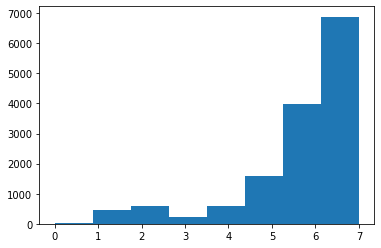

In [ ]:
obs_data_ceil = obs_data[:,1]
obs_data_ws = obs_data[:,4]
obs_data_wd = obs_data[:,5]
obs_data_sh = sh_data[:,5]
obs_data_cc_1000 = cc_data[:,12]
obs_data_cc_975 = cc_data[:,11]

names_list = ["obs_data_ceil", "obs_data_ws", "obs_data_wd", "obs_data_sh", "obs_data_cc_1000", "obs_data_cc_975"]

feats_list = [obs_data_ceil, obs_data_ws, obs_data_wd, obs_data_sh, obs_data_cc_1000, obs_data_cc_975]

allcombs = combinations([0,1,2,3,4,5], 3) 

var_list = []

report_list = []

for comb in allcombs :

  tuple_name = operator.itemgetter(*comb)(names_list)

  tuple_features = operator.itemgetter(*comb)(feats_list)

  var_list.append(tuple_name)

  report_list.append(automate_features(list(tuple_features)))
  

In [ ]:
print(len(report_list))

for i in range(20) :

  print(var_list[i])

  print(report_list[i])


In [ ]:
'''
('obs_data_ceil', 'obs_data_ws', 'obs_data_wd')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.15      0.38      0.22       115
           2       0.10      0.18      0.13       164
           3       0.00      0.00      0.00       104
           4       0.23      0.10      0.14       176
           5       0.30      0.08      0.13       376
           6       0.38      0.33      0.35      1030
           7       0.66      0.78      0.72      1609

    accuracy                           0.48      3576
   macro avg       0.23      0.23      0.21      3576
weighted avg       0.46      0.48      0.46      3576

('obs_data_ceil', 'obs_data_ws', 'obs_data_sh')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.19      0.62      0.29       115
           2       0.09      0.08      0.09       164
           3       0.00      0.00      0.00       104
           4       0.50      0.01      0.01       176
           5       0.27      0.18      0.21       376
           6       0.39      0.38      0.39      1030
           7       0.68      0.76      0.72      1609

    accuracy                           0.50      3576
   macro avg       0.27      0.25      0.21      3576
weighted avg       0.48      0.50      0.47      3576

('obs_data_ceil', 'obs_data_ws', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.19      0.39      0.25       115
           2       0.10      0.27      0.15       164
           3       0.00      0.00      0.00       104
           4       0.20      0.04      0.07       176
           5       0.25      0.08      0.12       376
           6       0.38      0.45      0.41      1030
           7       0.70      0.67      0.68      1609

    accuracy                           0.46      3576
   macro avg       0.23      0.24      0.21      3576
weighted avg       0.47      0.46      0.46      3576

('obs_data_ceil', 'obs_data_ws', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.16      0.37      0.22       115
           2       0.11      0.14      0.12       164
           3       0.00      0.00      0.00       104
           4       0.19      0.08      0.11       176
           5       0.29      0.10      0.15       376
           6       0.39      0.32      0.35      1030
           7       0.65      0.82      0.72      1609

    accuracy                           0.49      3576
   macro avg       0.22      0.23      0.21      3576
weighted avg       0.45      0.49      0.46      3576

('obs_data_ceil', 'obs_data_wd', 'obs_data_sh')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.16      0.30      0.21       115
           2       0.13      0.18      0.15       164
           3       0.00      0.00      0.00       104
           4       0.18      0.05      0.08       176
           5       0.28      0.15      0.20       376
           6       0.40      0.34      0.36      1030
           7       0.65      0.80      0.71      1609

    accuracy                           0.49      3576
   macro avg       0.23      0.23      0.22      3576
weighted avg       0.45      0.49      0.47      3576

('obs_data_ceil', 'obs_data_wd', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.17      0.32      0.22       115
           2       0.13      0.13      0.13       164
           3       0.00      0.00      0.00       104
           4       0.07      0.01      0.01       176
           5       0.34      0.16      0.22       376
           6       0.37      0.45      0.41      1030
           7       0.68      0.74      0.71      1609

    accuracy                           0.50      3576
   macro avg       0.22      0.23      0.21      3576
weighted avg       0.47      0.50      0.47      3576

('obs_data_ceil', 'obs_data_wd', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.18      0.42      0.25       115
           2       0.10      0.15      0.12       164
           3       0.00      0.00      0.00       104
           4       0.27      0.02      0.03       176
           5       0.28      0.16      0.20       376
           6       0.40      0.41      0.41      1030
           7       0.68      0.76      0.72      1609

    accuracy                           0.50      3576
   macro avg       0.24      0.24      0.22      3576
weighted avg       0.48      0.50      0.48      3576

('obs_data_ceil', 'obs_data_sh', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.18      0.13      0.15       115
           2       0.16      0.11      0.13       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.29      0.13      0.18       376
           6       0.35      0.37      0.36      1030
           7       0.62      0.82      0.71      1609

    accuracy                           0.50      3576
   macro avg       0.20      0.19      0.19      3576
weighted avg       0.42      0.50      0.45      3576

('obs_data_ceil', 'obs_data_sh', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.18      0.14      0.16       115
           2       0.17      0.11      0.13       164
           3       0.00      0.00      0.00       104
           4       0.29      0.01      0.02       176
           5       0.27      0.07      0.11       376
           6       0.36      0.37      0.37      1030
           7       0.62      0.85      0.71      1609

    accuracy                           0.51      3576
   macro avg       0.24      0.19      0.19      3576
weighted avg       0.44      0.51      0.45      3576

('obs_data_ceil', 'obs_data_cc_1000', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.30      0.17      0.21       115
           2       0.15      0.13      0.14       164
           3       0.00      0.00      0.00       104
           4       0.12      0.02      0.04       176
           5       0.29      0.22      0.25       376
           6       0.38      0.48      0.42      1030
           7       0.66      0.71      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.24      0.22      0.22      3576
weighted avg       0.46      0.49      0.47      3576

('obs_data_ws', 'obs_data_wd', 'obs_data_sh')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.17      0.20      0.18       115
           2       0.12      0.11      0.12       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.24      0.11      0.15       376
           6       0.36      0.46      0.40      1030
           7       0.65      0.72      0.68      1609

    accuracy                           0.48      3576
   macro avg       0.19      0.20      0.19      3576
weighted avg       0.43      0.48      0.45      3576

('obs_data_ws', 'obs_data_wd', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.20      0.28      0.23       115
           2       0.05      0.02      0.03       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.23      0.05      0.08       376
           6       0.36      0.46      0.40      1030
           7       0.64      0.76      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.18      0.20      0.18      3576
weighted avg       0.42      0.49      0.45      3576

('obs_data_ws', 'obs_data_wd', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.09      0.03      0.04       115
           2       0.03      0.01      0.01       164
           3       0.00      0.00      0.00       104
           4       0.14      0.02      0.04       176
           5       0.27      0.07      0.11       376
           6       0.34      0.34      0.34      1030
           7       0.59      0.86      0.70      1609

    accuracy                           0.49      3576
   macro avg       0.18      0.17      0.16      3576
weighted avg       0.40      0.49      0.43      3576

('obs_data_ws', 'obs_data_sh', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.17      0.13      0.15       115
           2       0.07      0.02      0.04       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.31      0.11      0.17       376
           6       0.36      0.31      0.33      1030
           7       0.57      0.86      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.19      0.18      0.17      3576
weighted avg       0.40      0.49      0.43      3576

('obs_data_ws', 'obs_data_sh', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.17      0.29      0.22       115
           2       0.11      0.07      0.09       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.39      0.02      0.05       376
           6       0.36      0.32      0.34      1030
           7       0.58      0.85      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.20      0.19      0.17      3576
weighted avg       0.42      0.49      0.42      3576

('obs_data_ws', 'obs_data_cc_1000', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.24      0.16      0.19       115
           2       0.06      0.02      0.03       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.25      0.11      0.16       376
           6       0.35      0.38      0.36      1030
           7       0.61      0.82      0.70      1609

    accuracy                           0.49      3576
   macro avg       0.19      0.19      0.18      3576
weighted avg       0.41      0.49      0.44      3576

('obs_data_wd', 'obs_data_sh', 'obs_data_cc_1000')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.12      0.17      0.14       115
           2       0.08      0.07      0.08       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.26      0.08      0.12       376
           6       0.36      0.43      0.39      1030
           7       0.63      0.76      0.69      1609

    accuracy                           0.48      3576
   macro avg       0.18      0.19      0.18      3576
weighted avg       0.42      0.48      0.44      3576

('obs_data_wd', 'obs_data_sh', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.17      0.10      0.12       115
           2       0.00      0.00      0.00       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.24      0.05      0.08       376
           6       0.32      0.29      0.30      1030
           7       0.57      0.88      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.16      0.16      0.15      3576
weighted avg       0.38      0.49      0.41      3576

('obs_data_wd', 'obs_data_cc_1000', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      0.15      0.19       115
           2       0.11      0.05      0.07       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.29      0.08      0.13       376
           6       0.33      0.35      0.34      1030
           7       0.59      0.83      0.69      1609

    accuracy                           0.49      3576
   macro avg       0.20      0.18      0.18      3576
weighted avg       0.41      0.49      0.43      3576

('obs_data_sh', 'obs_data_cc_1000', 'obs_data_cc_975')
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.18      0.09      0.12       115
           2       0.09      0.04      0.06       164
           3       0.00      0.00      0.00       104
           4       0.00      0.00      0.00       176
           5       0.24      0.09      0.13       376
           6       0.33      0.29      0.31      1030
           7       0.57      0.84      0.68      1609

    accuracy                           0.48      3576
   macro avg       0.18      0.17      0.16      3576
weighted avg       0.38      0.48      0.41      3576


check
0scompleted at 12:17 AM
'''

